# Assignment 2 - Supervised Machine Learning Fundamentals

## BELLA WENGAPPULY
Netid: bw165311

*Names of students you worked with on this assignment*: LIST HERE IF APPLICABLE (delete if not)

Note: this assignment falls under collaboration Mode 2: Individual Assignment – Collaboration Permitted. Please refer to the syllabus for additional information.

Instructions for all assignments can be found [here](https://github.com/kylebradbury/ids705/blob/master/assignments/_Assignment%20Instructions.ipynb), and is also linked to from the [course syllabus](https://kylebradbury.github.io/ids705/index.html).

Total points in the assignment add up to 90; an additional 10 points are allocated to presentation quality.

## Learning Objectives:
By successfully completing this assignment you will be able to...
- Explain the bias-variance tradeoff of supervised machine learning and the impact of model flexibility on algorithm performance
- Perform supervised machine learning training and performance evaluation
- Implement a k-nearest neighbors machine learning algorithm from scratch in a style similar to that of popular machine learning tools like `scikit-learn`
- Describe how KNN classification works, the method's reliance on distance measurements, and the impact of higher dimensionality on computational speed
- Apply regression (linear regression) and classification (KNN) supervised learning techniques to data and evaluate the performance of those methods
- Construct simple feature transformations for improving model fit in linear models
- Fit a `scikit-learn` supervised learning technique to training data and make predictions using it

In [ ]:
# MAC USERS TAKE NOTE:
# For clearer plots in Jupyter notebooks on macs, run the following line of code:
# %config InlineBackend.figure_format = 'retina'

---

# Conceptual Questions on Supervised Learning

## 1
**[4 points]**
For each part below, indicate whether we would generally expect the performance of a flexible statistical learning method to be *better* or *worse* than an inflexible method. Justify your answer.

1. The sample size $n$ is extremely large, and the number of predictors $p$ is small.  
  
  flexible *better* than inflexible because a large sample size decreases the probability of overfitting of flexible models, which generally perform better than inflexible models when feasible.

2. The number of predictors $p$ is extremely large, and the number of observations $n$ is small.  
  

flexible *worse* than inflexible because the small sample size makes a flexible method more likely to overfit.

3. The relationship between the predictors and response is highly non-linear.
   
flexible *better* than inflexible because inflexible methods are suited to simple/linear relationships while flexible methods are suitable for complex, non-linear relationships based on patterns found in large datasets.

4. The variance of the error terms, i.e. $\sigma^2 = Var(\epsilon)$, is extremely high  
  
flexible *worse* than inflexible because a flexible method would be prone to following the errors, resulting in overfitting. Inflexible methods would be less likely to overfit.


---

## 2
**[6 points]** For each of the following, (i) explain if each scenario is a classification or regression problem AND why, (ii) indicate whether we are most interested in inference or prediction for that problem AND why, and (iii) provide the sample size $n$ and number of predictors $p$ indicated for each scenario.

**(a)** We collect a set of data on the top 500 firms in the US. For each firm we record profit, number of employees, industry and the CEO salary. We are interested in understanding which factors affect CEO salary.  
  
  **ANSWER**
  **Regression** since the outcome variable, CEO salary, is a continuous variable, not a categorical one.  
  We are most interested in ***inference*** since we want to know what factors affect the CEO salary.   
  $n$ = 500, $p$=3  
     
**(b)** We are considering launching a new product and wish to know whether it will be a success or a failure. We collect data on 20 similar products that were previously launched. For each product we have recorded whether it was a success or failure, price charged for the product, marketing budget, competition price, and ten other variables.  
  
  **ANSWER**
  **Classification** since the outcome variable, success/failure, is a categorical variable, not a continuous one.  
  We are most interested in **prediction** since we want to know what factors determine success/failure.   
  $n$ = 20, $p$=13  

**(c)** We are interested in predicting the % change in the US dollar in relation to the weekly changes in the world stock markets. Hence we collect weekly data for all of 2012. For each week we record the % change in the dollar, the % change in the US market, the % change in the British market, and the % change in the German market.  
  
  **ANSWER**
  **Regression** since the outcome variable, % change in US dollar, is a continuous variable, not a categorical one.  
  We are most interested in **prediction** since we want to know what the % change in US dollar will be based on weekly changes in world stock markets.   
  $n$ = 52, $p$=3  


## 3
**[6 points] Classification using KNN**. The table below provides a training dataset containing six observations (a.k.a. samples) ($n=6$) each with three predictors (a.k.a. features) ($p=3$), and one qualitative response variable (a.k.a. target).

*Table 1. Training dataset with $n=6$ observations in $p=3$ dimensions with a categorical response, $y$*

| Obs. | $x_1$ | $x_2$ | $x_3$ | $y$   |
|------|-------|-------|-------|-------|
| **1**| 0     | 3     | 0     | Red   |
| **2**| 2     | 0     | 0     | Red   |
| **3**| 0     | 1     | 3     | Red   |
| **4**| 0     | 1     | 2     | Blue  |
| **5**| -1    | 0     | 1     | Blue  |
| **6**| 1     | 1     | 1     | Red   |

We want to use the above training dataset to make a prediction, $\hat{y}$, for an unlabeled test data observation where $x_1=x_2=x_3=0$ using $K$-nearest neighbors. You are given some code below to get you started. *Note: coding is only required for part (a), for (b)-(d) please provide your reasoning based on your answer to part (a)*.

**(a)** Compute the Euclidean distance between each observation and the test point, $x_1=x_2=x_3=0$. Present your answer in a table similar in style to Table 1 with observations 1-6 as the row headers.

**(b)** What is our prediction, $\hat{y}$, when $K=1$ for the test point? Why?

**(c)** What is our prediction, $\hat{y}$, when $K=3$ for the test point? Why?

**(d)** If the Bayes decision boundary (the optimal decision boundary) in this problem is highly nonlinear, then would we expect the *best* value of $K$ to be large or small? Why?

**ANSWER** 3A

In [ ]:
import numpy as np
import pandas as pd

X = np.array([[ 0, 3, 0],
              [ 2, 0, 0],
              [ 0, 1, 3],
              [ 0, 1, 2],
              [-1, 0, 1],
              [ 1, 1, 1]])
y = np.array(['r','r','r','b','b','r'])
testx = np.array([[0,0,0]])
# compute Euclidean distance b/t each obs and testx

dst = np.array([round(np.linalg.norm(X[x] - testx), ndigits=2) for x in X])
dst = dst.reshape(6,1)

indx = [i for i in range(1,7)]
dfdst = pd.DataFrame(indx, columns=['Obs.'])
dfdst["Eudistance"] = dst
dfdst=dfdst.set_index('Obs.')
dfdst

,Eudistance
Obs.,
1,4.80
2,5.29
3,4.24
4,4.80
5,4.00
6,3.46


**ANSWER** 3B  
RED. If K=1, the nearest neighbor to 0,0,0 is selected, which is observation 6 with a distance of 3.46. Observation 6 is Red.

**ANSWER** 3C  
RED. The closes 3 Observations are 6 (R), 5 (B), and 3(R). There are 2 R to the 1 B, so prediction is Red.

**ANSWER** 3D  
LOW. A non linear Bayes decision boundary implies flexibility of the model. Low values of K allow for a flexible model with a bendy decision boundary.

---

## 4
**[18 points] Build your own classification algorithm**.

**(a)** Build a working version of a binary KNN classifier using the skeleton code below. We'll use the `sklearn` convention that a supervised learning algorithm has the methods `fit` which trains your algorithm (for KNN that means storing the data) and `predict` which identifies the K nearest neighbors and determines the most common class among those K neighbors. *Note: Most classification algorithms typically also have a method `predict_proba` which outputs the confidence score of each prediction, but we will explore that in a later assignment.*

**(b)** Load the datasets to be evaluated here. Each includes training features ($\mathbf{X}$), and test features ($\mathbf{y}$) for both a low dimensional dataset ($p = 2$ features/predictors) and a higher dimensional dataset ($p = 100$ features/predictors). For each of these datasets there are $n=1000$ observations of each. They can be found in the `data` subfolder in the `assignments` folder on github. Each file is labeled similar to `A2_X_train_low.csv`, which lets you know whether the dataset is of features, $X$, targets, $y$; training or testing; and low or high dimensions.

**(c)** Train your classifier on first the low dimensional dataset and then the high dimensional dataset with $k=5$. Evaluate the classification performance on the corresponding test data for each of those trained models. Calculate the time it takes each model to make the predictions and the overall accuracy of those predictions for each corresponding set of test data - state each.

**(d)** Compare your implementation's accuracy and computation time to the scikit learn [KNeighborsClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) class. How do the results and speed compare to your implementation?

**(e)** Some supervised learning algorithms are more computationally intensive during training than testing. What are the drawbacks of the prediction process being slow? In what cases in practice might slow testing (inference) be more problematic than slow training?

**ANSWER**: 4A

In [ ]:
def euclidean_dist(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

In [62]:
# Skeleton code for part (a) to write your own kNN classifier
# import package from statistics module for calculating mode
from collections import Counter

class Knn:
# k-Nearest Neighbor class object for classification training and testing
    def __init__(self):
        self.x_train = None
        self.y_train = None
    def fit(self, x, y):
        # Save the training data to properties of this class
        self.x_train = x
        self.y_train = y

    def predict(self, x, k):
        y_hat = [] # Variable to store the estimated class label for
        # Calculate the distance from each vector in x to the training data
        for h in x:
          dst = [euclidean_dist(h, i) for i in self.x_train]
          # print("dst", dst, type(dst))

          # get the closest k neighbors' indices without rearranging order of dst
          k_indices = np.argsort(dst)[:k]
          # print("k_indices", k_indices, type(k_indices))
          knlabels = [int(self.y_train[i][0]) for i in k_indices]
          # print("knlabels", knlabels, type(knlabels))

          # get majority vote of classes in knn, append to y_hat
          label = Counter(knlabels[:]).most_common()[0][0]
          # print("most common label", label, type(label))
          y_hat.append(label)

          # Return the estimated targets
        return y_hat

# Metric of overall classification accuracy
#  (a more general function, sklearn.metrics.accuracy_score, is also available)
def accuracy(y,y_hat):
    nvalues = len(y)
    accuracy = sum(y == y_hat) / nvalues
    return accuracy

**ANSWER**: 4B

In [30]:
# import data from github

path = 'https://raw.githubusercontent.com/bw123111/csci547_ML/refs/heads/main/assignments/data/'
filenamesx = ['A2_X_test_high.csv',
             'A2_X_test_low.csv',
             'A2_X_train_high.csv',
             'A2_X_train_low.csv',
             ]
filenamesy = ['A2_y_test_high.csv',
             'A2_y_test_low.csv',
             'A2_y_train_high.csv',
             'A2_y_train_low.csv',
             ]

x_test_high = pd.read_csv(path + filenamesx[0], header=None)
x_test_low = pd.read_csv(path + filenamesx[1], header=None)
y_test_high = pd.read_csv(path + filenamesy[0], header=None)
y_test_low = pd.read_csv(path + filenamesy[1], header=None)
x_train_high = pd.read_csv(path + filenamesx[2], header=None)
x_train_low = pd.read_csv(path + filenamesx[3], header=None)
y_train_high = pd.read_csv(path + filenamesy[2], header=None)
y_train_low = pd.read_csv(path + filenamesy[3], header=None)

**ANSWER**: 4C: runtime and accuracy for low, then high dimensional data

In [75]:
from sklearn.metrics import accuracy_score
from time import time
k = 5

# low dimensional data
start = time()
knn_low = Knn()
knn_low.fit(x_train_low.values, y_train_low.values)
y_pred_low = knn_low.predict(x_test_low.values, k)
end = time()
time_low = end - start

In [ ]:
# high dimensional data
start = time()
knn_high = Knn()
knn_high.fit(x_train_high.values, y_train_high.values)
y_pred_high = knn_high.predict(x_test_high.values, k)
end = time()
time_high = end - start

In [76]:
# My implementation metrics
print("low dimensional accuracy:", accuracy_score(y_test_low, y_pred_low))
print(f"low dimensional runtime: {time_low:.3f}")
print("high dimensional accuracy:", accuracy_score(y_test_high, y_pred_high))
print(f"high dimensional runtime: {time_high:.3f}")

low dimensional accuracy: 0.925
low dimensional runtime: 9.112
high dimensional accuracy: 0.993
high dimensional runtime: 8.440


**ANSWER** 4D: compare stats to scikitlearn KNN  
Runtime with scikit learn KNN is much faster than with my implementation by several orders of magnitude (my implementation takes seconds, the sklearn implementation takes thousandths of a second). The accuracy is identical for high dimensional data. My implementation has slightly higher accuracy for low dimensional data.

In [91]:
# adjust y data from 2d array to 1d array
y_train_low_1d = np.ravel(y_train_low)
y_train_high_1d = np.ravel(y_train_high)

In [102]:
from sklearn.neighbors import KNeighborsClassifier
weight = 'uniform'

# low dimensional data
start = time()
sknn_low = KNeighborsClassifier(n_neighbors=k, weights=weight)
sknn_low.fit(x_train_low.values, y_train_low_1d)
y_pred_low_sk = sknn_low.predict(x_test_low.values)
end = time()
time_sk_low = end - start

In [103]:
# high dimensional data
start = time()
sknn_high = KNeighborsClassifier(n_neighbors=k, weights=weight)
sknn_high.fit(x_train_high.values, y_train_high_1d)
y_pred_high_sk = sknn_high.predict(x_test_high.values)
end = time()
time_sk_high = end - start

In [104]:
# Scikit Learn metrics
print("low dimensional accuracy:", accuracy_score(y_test_low, y_pred_low_sk))
print(f"low dimensional runtime: {time_sk_low:.3f}")
print("high dimensional accuracy:", accuracy_score(y_test_high, y_pred_high_sk))
print(f"high dimensional runtime: {time_sk_high:.3f}")

low dimensional accuracy: 0.917
low dimensional runtime: 0.008
high dimensional accuracy: 0.993
high dimensional runtime: 0.016


**ANSWER** 4E  
The drawbacks of the prediction process being slow are: longer runtimes, which limit the amount of data that can be processed without investing in more powerful hardware systems. Longer runtimes can slow down a project, particularly if there are errors in the code/results that need to be rectified.  
Slow testing can be more problematic than slow training in projects that require quick results for rapidly updating data, such as emergency/disaster response or warfare. If a prediction is slow to process, the results may be outdated by the time they are produced due to the rapid changes of a natural disaster scene or battlefield.

---

## 5
**[20 points] Bias-variance tradeoff: exploring the tradeoff with a KNN classifier**. This exercise will illustrate the impact of the bias-variance tradeoff on classifier performance by investigating how model flexibility impacts classifier decision boundaries. For this problem, please us Scikit-learn's KNN implementation rather than your own implementation, as you did at the end of the last question.

**(a)** Create a synthetic dataset (with both features and targets). Use the [`make_moons`](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html#sklearn.datasets.make_moons) module with the parameter `noise=0.35` to generate 1000 random samples.

**(b)** Visualize your data: scatterplot your random samples with each class in a different color.

**(c)** Create 3 different data subsets by selecting 100 of the 1000 data points at random three times (with replacement). For each of these 100-sample datasets, fit three separate k-Nearest Neighbor classifiers with: $k = \{1, 25, 50\}$. This will result in 9 combinations (3 datasets, each with 3 trained classifiers).

**(d)** For each combination of dataset and trained classifier plot the decision boundary (similar in style to Figure 2.15 from *Introduction to Statistical Learning*). This should form a 3-by-3 grid. Each column should represent a different value of $k$ and each row should represent a different dataset.

**(e)** What do you notice about the difference between the rows and the columns. Which decision boundaries appear to best separate the two classes of data? Which decision boundaries vary the most as the data change?

**(f)** Explain the bias-variance tradeoff using the example of the plots you made in this exercise and its implications for training supervised machine learning algorithms.

Notes and tips for plotting decision boundaries (as in part d):
- *Resource for plotting decision boundaries with meshgrid and contour: https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html*
- If you would like to change the colors of the background, and do not like any of the existing cmap available in matplotlib, you can make your own cmap using the 2 sets of rgb values. Sample code (replace r, g, b with respective rgb values):

In [106]:
# from matplotlib.colors import LinearSegmentedColormap
# newcmp = LinearSegmentedColormap.from_list("new", [(r/255, g/255, b/255), (r/255, g/255, b/255)], N=2)

**ANSWER** 5A synthetic dataset

In [166]:
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt

data5x_train, data5y_train = make_moons(n_samples=1000, noise=0.35)
data5x_test, data5y_test = make_moons(n_samples=1000, noise=0.35)
# data5y = data5y.reshape(-1,1)
# data5 = np.concatenate((data5x, data5y), axis=1)


**ANSWER** 5B scatterplot

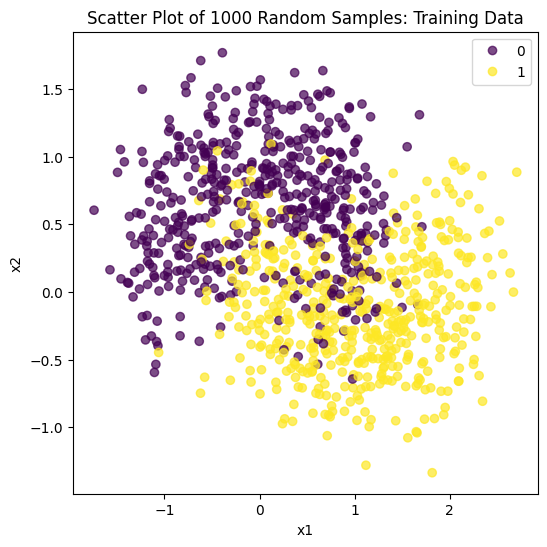

In [191]:
plt.figure(figsize=(6,6))

ax1 = plt.scatter(
    x=data5x_train[:,0],
    y=data5x_train[:,1],
    c=data5y_train,
    alpha = 0.7
)
plt.title('Scatter Plot of 1000 Random Samples: Training Data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(handles=ax1.legend_elements()[0], labels=['0','1'])

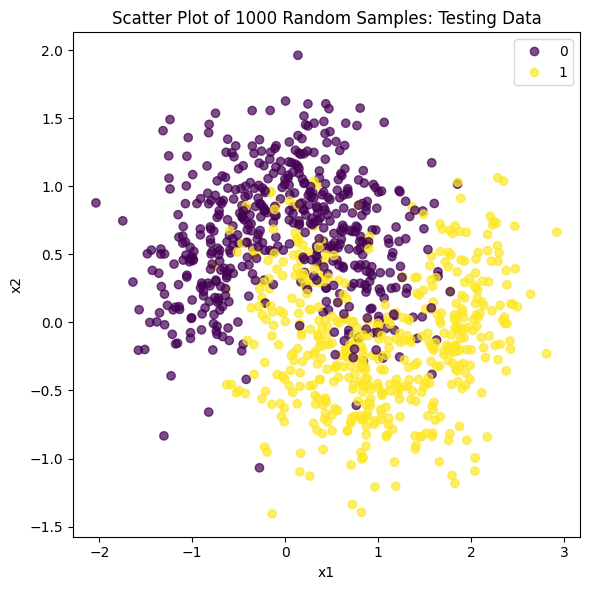

In [190]:
plt.figure(figsize=(6,6))
ax2 = plt.scatter(
    x=data5x_test[:,0],
    y=data5x_test[:,1],
    c=data5y_test,
    alpha = 0.7
)
plt.title('Scatter Plot of 1000 Random Samples: Testing Data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(handles=ax2.legend_elements()[0], labels=['0','1'])

plt.tight_layout()
plt.show()

**ANSWER** 5C data subsetting, fitting with various k = [1,25,50]

In [243]:
import random
k = [1,25,50]
random.seed(123)
subset1 = [data5x_train[random.sample(range(0,1000), 100)], data5y_train[random.sample(range(0,1000), 100)]]
random.seed(1234)
subset2 = [data5x_train[random.sample(range(0,1000), 100)], data5y_train[random.sample(range(0,1000), 100)]]
random.seed(12345)
subset3 = [data5x_train[random.sample(range(0,1000), 100)], data5y_train[random.sample(range(0,1000), 100)]]
subsets = [subset1, subset2, subset3]
knn_sets = [None] * 9

for i in range(3):
  for j in range(3):
    knn_sets[3*i+j] = KNeighborsClassifier(n_neighbors=k[j])
    knn_sets[3*i+j].fit(subsets[i][0], subsets[i][1])

**ANSWER** 5D plot decision boundaries as 3x3 grid. cols = k, rows = datasets  
  
  Referenced [this document](https://ronaldnhondova.com/?rara-portfolio=bias-variance-trade-off-in-with-knns) for help creating the plots. Cleaned up the code, asked chatGPT how and why the meshgrid was necessary, and messed around with displaying the data in different ways (e.g. with a tricountour of the training points, displaying test data points on the plots).

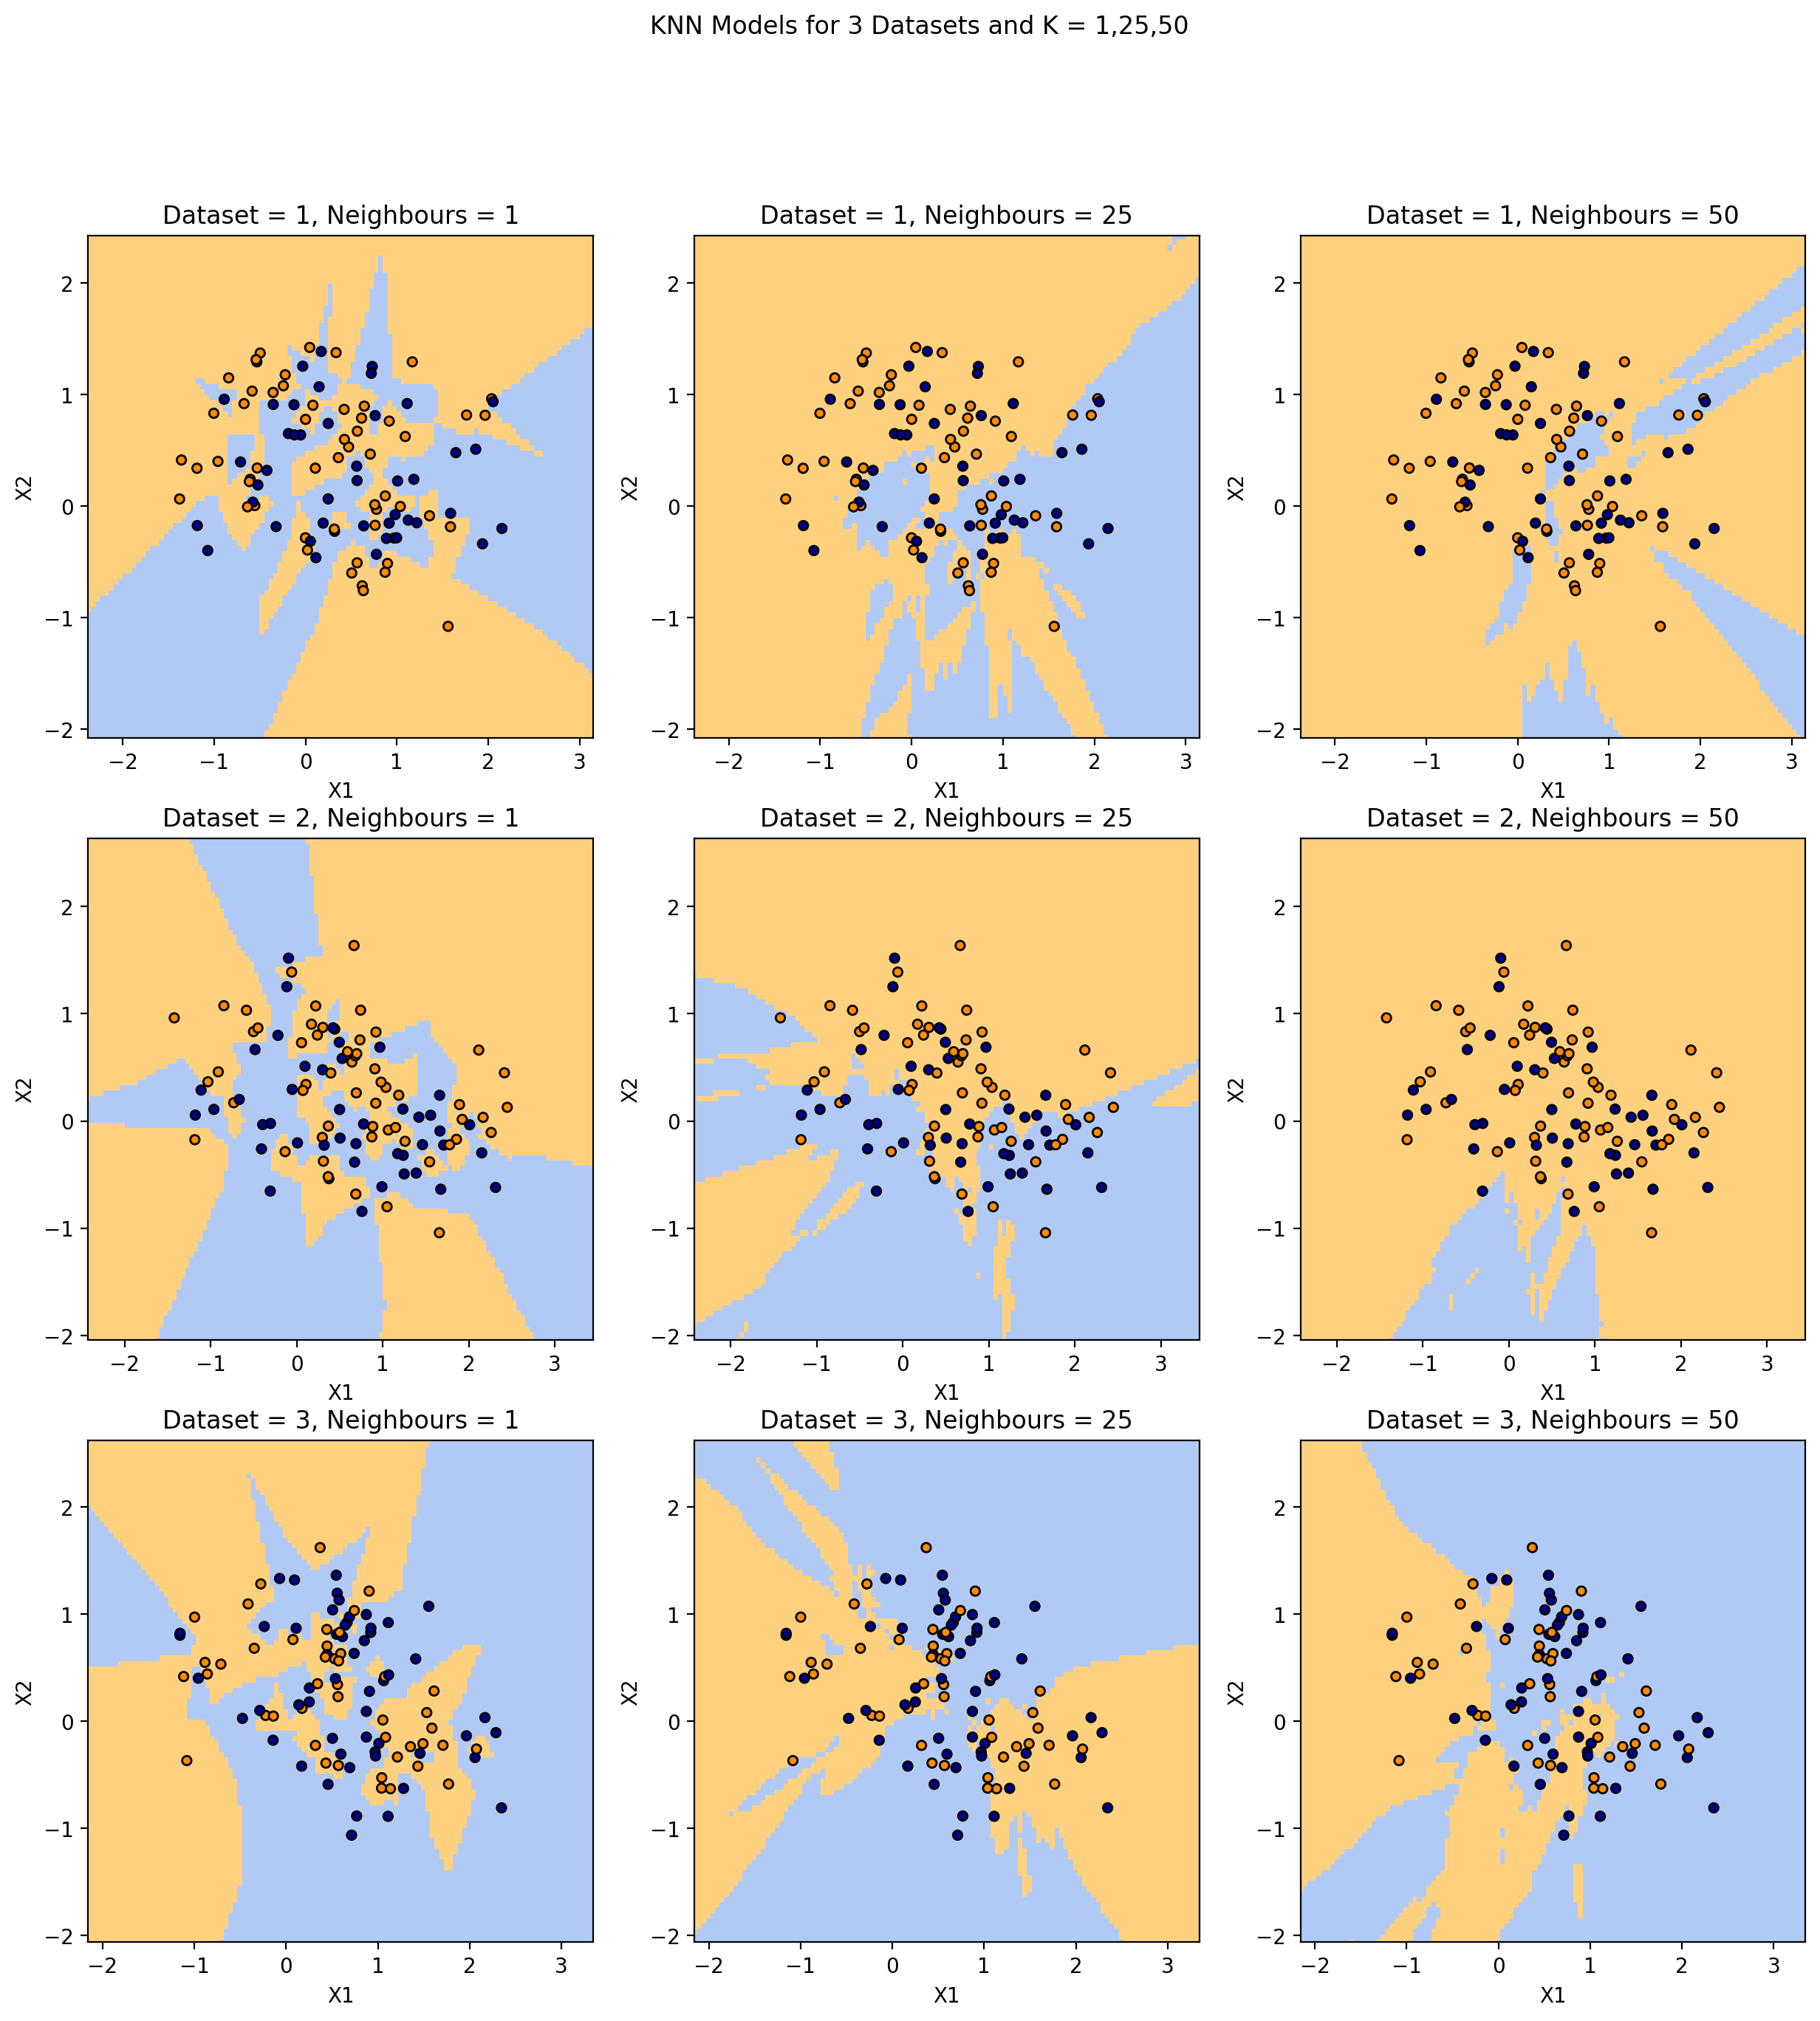

In [304]:
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets

# test_x_100 = data5x_test[random.sample(range(0,1000), 100)]
# test_y_100 = data5y_test[random.sample(range(0,1000), 100)]

# Create color maps
cmap_light = ListedColormap(['orange', 'cornflowerblue'])
cmap_bold = ListedColormap(['darkorange', 'darkblue'])

subplt = 0    # increment subplot index
fig, axs = plt.subplots(3,3,figsize=(15,15))

cntr = 0    # increment knn_sets index
for j, subset in enumerate([subset1, subset2, subset3], start=1):
    X, y = subset
    subplt = 0
    for k in [1, 25, 50]:
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# use code below to show decision boundaries based on training data points using tricountour
        # # predict classifications of knn based on training data
        # Z = knn_sets[cntr].predict(X)

        # # Put the predicted decision boundary into a color plot
        # axs[j-1, subplt].tricontourf(X[:, 0], X[:, 1], Z, cmap=cmap_light, levels=np.arange(-0.5, 2), alpha=0.5)

# Create meshgrid
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                             np.arange(y_min, y_max, 0.05))

        # Predict on mesh
        Z = knn_sets[cntr].predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot decision boundary with pcolormesh
        axs[j-1, subplt].pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto', alpha=0.5)

        # Plot 100 randomly sampled test data points (1000 is waaay to cluttered)
        axs[j-1, subplt].scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
        axs[j-1, subplt].set_xlim([x_min, x_max])
        axs[j-1, subplt].set_ylim([y_min, y_max])
        axs[j-1, subplt].set(title=f"Dataset = {j}, Neighbours = {k}", xlabel='X1', ylabel='X2')

        subplt += 1
        cntr += 1

fig.suptitle('KNN Models for 3 Datasets and K = 1,25,50')
plt.show()

**ANSWER** 5E
The rows, representing different datasets, have slightly different distributions of points on the graph. All the subsets have very mixed datapoints, which results in interesting decision boundaries. The columns, representing different values of K, or nearest neighbors, drastically change the decision boundaries. Low values of K create more heterogeneous boundaries, and high values result in large areas of contiguous color.  
Decision boundaries within a dataset are most consistent, with K=25 performing best to separate the two classes. The decision boundaries of K=1 plots vary immensely as the data changes due to their highly flexible nature.

**ANSWER** 5F  
Changes in data subsets show bias, while changes in K show variation. The large differences in decision boundaries between subsets shows that bias precludes the changes that are then shown through variation when modifying K. Variability can exist in any dataset when K is changed, but how that variation is distributed is informed by the bias in the data.  
So, we should strive to minimize data bias by collecting representative training/testing data, then find the optimum value of K that has low error on test data (medium variability).

---

## 6
**[18 points] Bias-variance trade-off II: Quantifying the tradeoff**. This exercise explores the impact of the bias-variance tradeoff on classifier performance by looking at the performance on both training and test data.

Here, the value of $k$ determines how flexible our model is.

**(a)** Using the function created earlier to generate random samples (using the `make_moons` function setting the `noise` parameter to 0.35), create a new set of 1000 random samples, and call this dataset your test set and the previously created dataset your training set.

**(b)** Train a kNN classifier on your training set for $k = 1,2,...500$. Apply each of these trained classifiers to both your training dataset and your test dataset and plot the classification error (fraction of incorrect predictions).

**(c)** What trend do you see in the results?

**(d)** What values of $k$ represent high bias and which represent high variance?

**(e)** What is the optimal value of $k$ and why?

**(f)** In KNN classifiers, the value of k controls the flexibility of the model - what controls the flexibility of other models?

**ANSWER** 6A

In [250]:
test_x, test_y = datasets.make_moons(n_samples=1000,noise=0.35)
# data5x_train, data5y_train for test data.

**ANSWER** 6B

In [268]:
y_pred_test = []
y_pred_train = []
min_test_error = 1
min_test_error_k = 0

# run KNN for K = 1 to 500
for j in range(1,501):
    exec("knn%s=KNeighborsClassifier(n_neighbors=%s)" % (j,j))
    exec("knn%s.fit(data5x_train,data5y_train)" % (j))
    exec("y_pred_test.append(1-knn%s.score(test_x,test_y))" % (j))  # mean test error
    exec("y_pred_train.append(1-knn%s.score(data5x_train,data5y_train))" % (j))  # mean train error
    # find the k with the lowest test error
    if y_pred_test[-1] < min_test_error:
        min_test_error = y_pred_test[-1]
        min_test_error_k = j

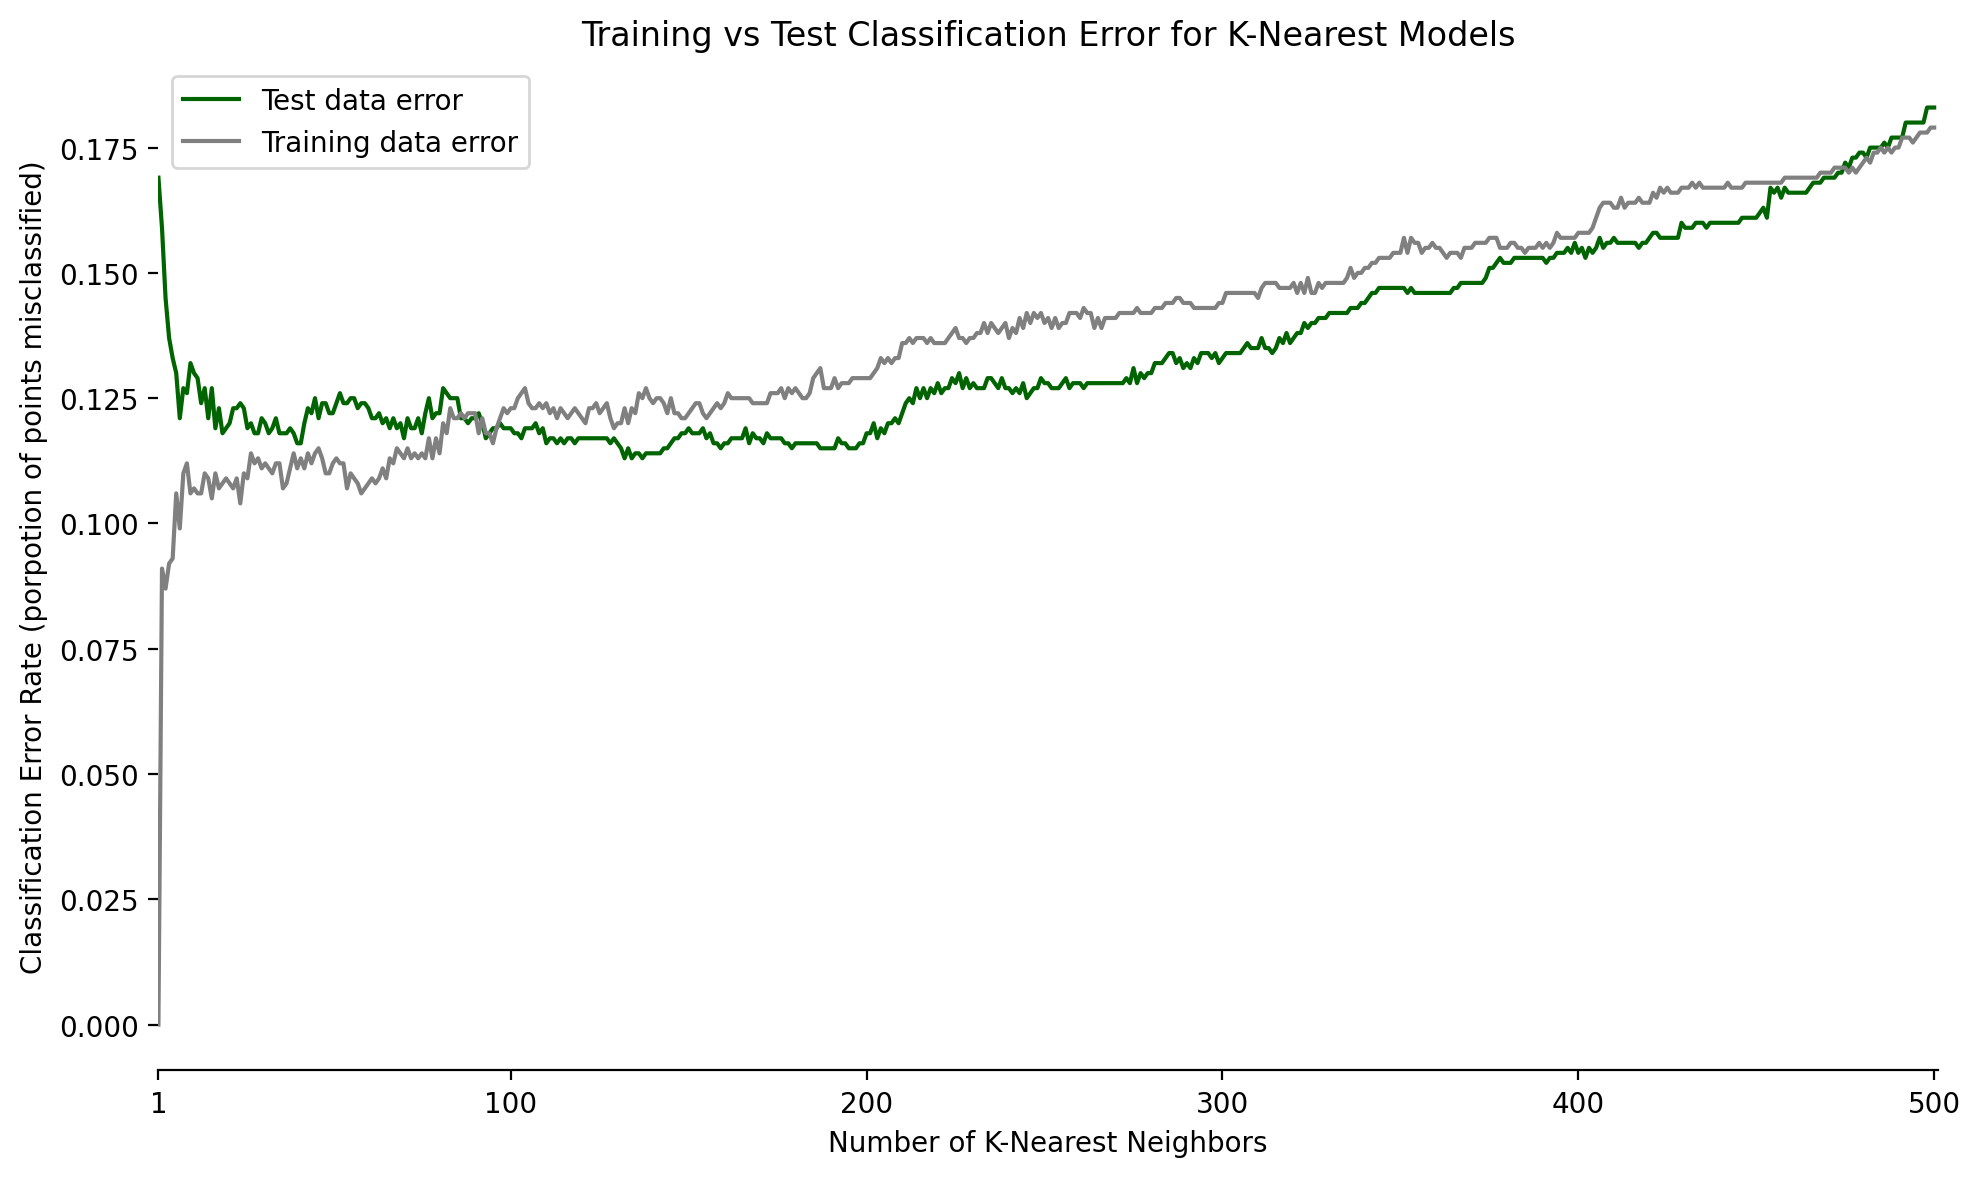

In [276]:
# Create the plot
plt.figure(figsize=(10,6))

# plot 2 lines, the test data error and training data error (calculated as 1 minus
# the "knn score", a mean measure of accuracy)
plt.plot(range(1,501),y_pred_test,color='darkgreen',label='Test data error')
plt.plot(range(1,501),y_pred_train,color='grey',label='Training data error')
plt.xlim(1, 501)
plt.xticks((1,100,200,300,400,500))

# Hide the right and top graph edges for aesthetics
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.legend()
plt.title('Training vs Test Classification Error for K-Nearest Models')
plt.xlabel('Number of K-Nearest Neighbors')
plt.ylabel('Classification Error Rate (porpotion of points misclassified)')
plt.tight_layout()
plt.show()

**ANSWER** 6C  


**ANSWER** 6D

**ANSWER** 6E

**ANSWER** 6F

---

## 7
**[18 points] Linear regression and nonlinear transformations**. Linear regression can be used to model nonlinear relationships when feature variables are properly transformed to represent the nonlinearities in the data. In this exercise, you're given training and test data contained in files "A2_Q7_train.csv" and "A2_Q7_test.csv" in the "data" folder for this assignment. Your goal is to develop a regression algorithm from the training data that performs well on the test data.

*Hint: Use the scikit learn [LinearRegression](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) module.*

**(a)** Create a scatter plot of your training data.

**(b)** Estimate a linear regression model ($y = a_0 + a_1 x$) for the training data and calculate both the $R^2$ value and mean square error for the fit of that model for the training data. Also provide the equation representing the estimated model (e.g. $y = a_0 + a_1 x$, but with the estimated coefficients inserted. Consider this your baseline model against which you will compare other model options. *Evaluating performance on the training data is not a measure of how well this model would generalize to unseen data. We will evaluate performance on the test data once we see our models fit the training data decently well.*  

**(c)** If features can be nonlinearly transformed, a linear model may incorporate those non-linear feature transformation relationships in the training process. From looking at the scatter plot of the training data, choose a transformation of the predictor variable, $x$ that may make sense for these data. This will be a multiple regression model of the form $y = a_0 + a_1 z_1 + a_2 z_2 + \ldots + a_n z_n$. Here $z_i$ could be any transformations of x - perhaps it's $\frac{1}{x}$, $log(x)$, $sin(x)$, $x^k$ (where $k$ is any power of your choosing). Provide the estimated equation for this multiple regression model (e.g. if you chose your predictors to be $z_1 = x$ and $z_2 = log(x)$, your model would be of the form $y = a_0 + a_1 x + a_2 log(x)$. Also provide the $R^2$ and mean square error of the fit for the training data.

**(d)** Visualize the model fit to the training data. Using both of the models you created in parts (b) and (c), plot the original data (as a scatter plot) AND the curves representing your models (each as a separate curve) from (b) and (c).

**(e)** Now its time to compare your models and evaluate the generalization performance on held out test data. Using the models above from (b) an (c), apply them to the test data and estimate the $R^2$ and mean square error of the test dataset.

**(f)** Which models perform better on the training data, and which on the test data? Why?

**(g)** Imagine that the test data were significantly different from the training dataset. How might this affect the predictive capability of your model? How would the accuracy of generalization performance be impacted? Why?

*To help get you started - here's some code to help you load in the data for this exercise (you'll just need to update the path)*:

In [ ]:
import numpy as np
import pandas as pd

path = './data/'
train = pd.read_csv(path + 'A2_Q7_train.csv')
test = pd.read_csv(path + 'A2_Q7_test.csv')

x_train = train.x.values
y_train = train.y.values

x_test = test.x.values
y_test = test.y.values

**ANSWER**